In [7]:
from google.colab import files
uploaded = files.upload()

Saving ILPD.csv to ILPD (1).csv


RFECV Time: 25.68006157875061
SHAP Time: 2.2976503372192383
Final Selected Features: ['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase']

Feature Importance Table:
                      Feature  RF Importance  SHAP Importance  Fusion Score
4        Alkaline_Phosphotase       0.147617         0.060986      0.112964
6  Aspartate_Aminotransferase       0.135581         0.046652      0.100010
0                         Age       0.129356         0.041893      0.094371
5    Alamine_Aminotransferase       0.126659         0.045074      0.094025
2             Total_Bilirubin       0.103737         0.045387      0.080397
8                     Albumin       0.091495         0.023871      0.064445
7              Total_Protiens       0.091391         0.020607      0.063078
3            Direct_Bilirubin       0.073745         0.042125      0.061097
9  Albumin_and_Globulin_Ratio       0.081140         0.022174      0.057554
1                  

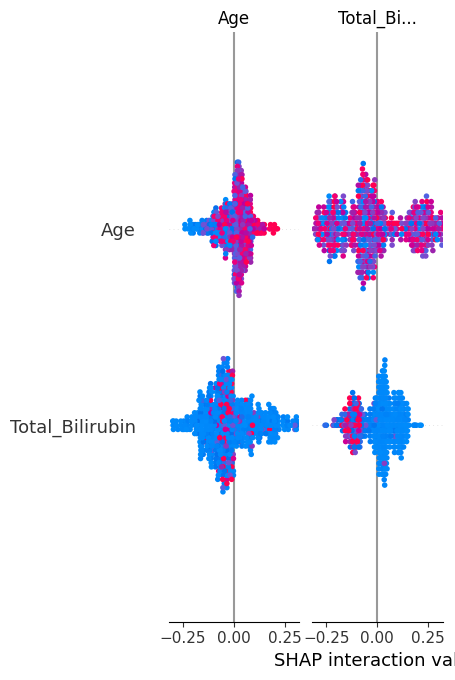

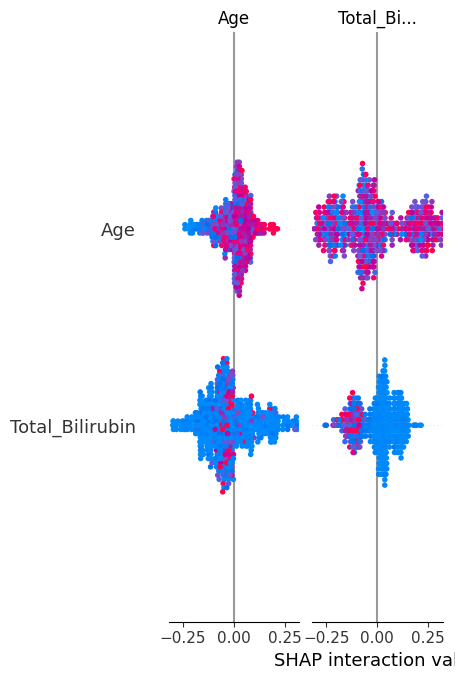

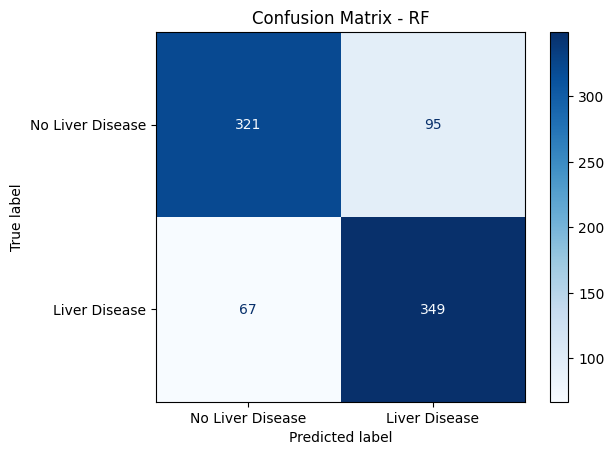

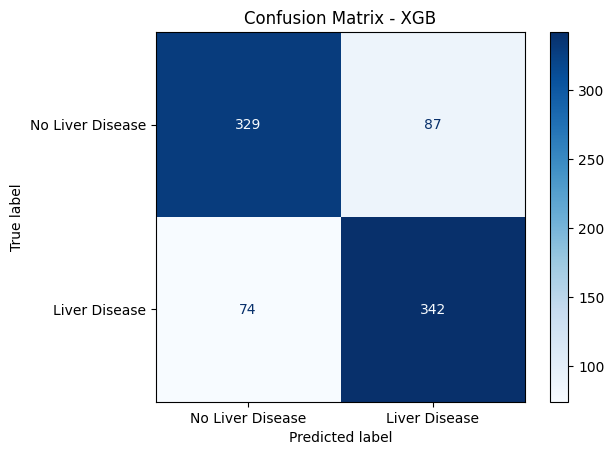

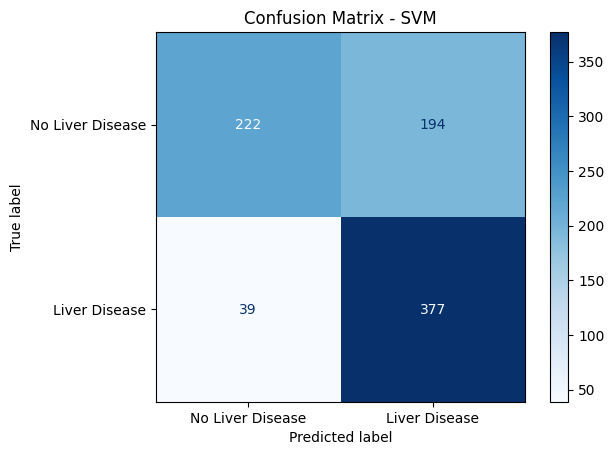

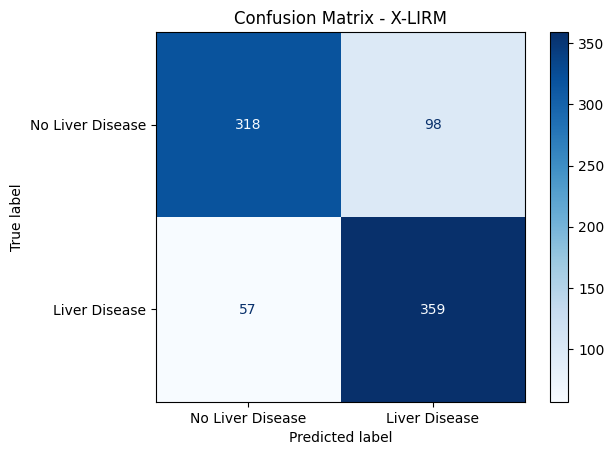


Execution Time Summary
RFECV Feature Selection: 25.68006157875061
SHAP Computation: 2.2976503372192383
SMOTE Balancing: 0.0044782161712646484
RF Training Time: 3.4086833000183105
XGB Training Time: 0.6682395935058594
SVM Training Time: 0.8713531494140625
Meta Learner Time: 0.000141143798828125

===== Misclassified Samples =====

   Actual  Predicted  Sample_Index
0       0          1             0
1       0          1             3
2       0          1             6
3       1          0            12
4       0          1            14
Total Misclassified Samples: 155


In [8]:
# ============================================================
# ILPD: LLM-Assisted Feature Selection + SHAP + Meta-Learner
# ============================================================

# -------------------------
# 1. Install libraries
# -------------------------
!pip install -q pandas numpy scikit-learn xgboost shap imbalanced-learn optuna

# -------------------------
# 2. Imports
# -------------------------
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

# -------------------------
# 3. Load & preprocess data
# -------------------------
df = pd.read_csv("ILPD.csv")

df.fillna(df.median(numeric_only=True), inplace=True)
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

X = df.drop('Dataset', axis=1)
y = df['Dataset'].replace({1: 0, 2: 1})

X_scaled = StandardScaler().fit_transform(X)

# -------------------------
# 4. RFECV (10-fold)
# -------------------------
rf_base = RandomForestClassifier(
       random_state=42,
    n_jobs=-1
)

rfecv = RFECV(
    estimator=rf_base,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

start = time.time()

rfecv.fit(X_scaled, y)

rfecv_time = time.time() - start
print("RFECV Time:", rfecv_time)





X_sel = X_scaled[:, rfecv.support_]
sel_features = X.columns[rfecv.support_]

rf_importance = rfecv.estimator_.feature_importances_

# -------------------------
# 5. SHAP (same feature space)
# -------------------------
rf_shap = RandomForestClassifier(
     random_state=42,
    n_jobs=-1
)
rf_shap.fit(X_sel, y)

start = time.time()

explainer = shap.TreeExplainer(rf_shap)
shap_vals = explainer.shap_values(X_sel)

shap_time = time.time() - start
print("SHAP Time:", shap_time)

if isinstance(shap_vals, list):
    shap_vals = np.stack(shap_vals)  # (classes, samples, features)
else:
    shap_vals = shap_vals[np.newaxis, ...]

shap_importance = np.mean(np.abs(shap_vals), axis=1)  # (classes, features)
shap_importance = np.mean(shap_importance, axis=0)    # (features,)

# -------------------------
# 6. LLM-Assisted Feature Fusion
# -------------------------
# -------------------------
# 6. LLM-Assisted Feature Fusion (FINAL FIX)
# -------------------------

# SHAP importance may be (features, classes)
if shap_importance.ndim == 2:
    shap_importance = shap_importance.mean(axis=1)

# SAFE fusion
combined_score = 0.6 * rf_importance + 0.4 * shap_importance
threshold = np.median(combined_score)

final_idx = np.where(combined_score >= threshold)[0]
X_final = X_sel[:, final_idx]
final_features = sel_features[final_idx]

print("Final Selected Features:", list(final_features))

# -------------------------
# 6A. Create Feature Importance Table
# -------------------------

feature_table = pd.DataFrame({
    "Feature": sel_features,
    "RF Importance": rf_importance,
    "SHAP Importance": shap_importance,
    "Fusion Score": combined_score
})

# Sort by fusion score
feature_table = feature_table.sort_values(by="Fusion Score", ascending=False)

print("\nFeature Importance Table:")
print(feature_table)

# Save for paper
feature_table.to_csv("feature_importance_table.csv", index=False)


final_feature_table = feature_table[feature_table["Fusion Score"] >= threshold]

print("\nFinal Selected Features Table:")
print(final_feature_table)

# -------------------------
# 7. SMOTE
# -------------------------
start = time.time()

X_bal, y_bal = SMOTE(random_state=42).fit_resample(X_final, y)

smote_time = time.time() - start
print("SMOTE Time:", smote_time)

# -------------------------
# 8. Base models
# -------------------------
base_models = {
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier( random_state=42),
    #"GB": GradientBoostingClassifier(random_state=42),
   # "ET": ExtraTreesClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# -------------------------
# 9. Meta-features (10-fold)
# -------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

meta_X = []
model_scores = []
model_times = {}
for name, model in base_models.items():
    start = time.time()

    probs = cross_val_predict(
        model,
        X_bal,
        y_bal,
        cv=skf,
        method="predict_proba"
    )[:,1]

    model_times[name] = time.time() - start

    meta_X.append(probs)
    model_scores.append(accuracy_score(y_bal, (probs > 0.5).astype(int)))

meta_X = np.vstack(meta_X).T
model_scores = np.array(model_scores)

# -------------------------
# 10. LLM Meta-Learner (Reasoned Weighting)
# -------------------------
llm_weights = model_scores / model_scores.sum()

start = time.time()

meta_score = np.dot(meta_X, llm_weights)
y_meta = (meta_score > 0.5).astype(int)

meta_time = time.time() - start

# -------------------------
# 11. Final Evaluation
# -------------------------
final_acc = accuracy_score(y_bal, y_meta)
print(f"\nLLM Meta-Learner Accuracy (10-fold): {final_acc:.4f}")


from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# -------------------------
# Metrics for Base Classifiers
# -------------------------
print("\n--- Base Classifier Metrics ---")
base_results = {}
for name, model in base_models.items():
    y_pred = cross_val_predict(model, X_bal, y_bal, cv=skf, method="predict")
    y_prob = cross_val_predict(model, X_bal, y_bal, cv=skf, method="predict_proba")[:,1]
    tn, fp, fn, tp = confusion_matrix(y_bal, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    base_results[name] = {
        "Accuracy": accuracy_score(y_bal, y_pred),
        "Precision": precision_score(y_bal, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Recall": recall_score(y_bal, y_pred),
        "F1": f1_score(y_bal, y_pred),
        "AUC": roc_auc_score(y_bal, y_prob)
    }

    print(f"\n{name}")
    for k,v in base_results[name].items():
        print(f"{k}: {v:.4f}")

# -------------------------
# Metrics for LLM Meta-Learner
# -------------------------
tn, fp, fn, tp = confusion_matrix(y_bal, y_meta).ravel()
sensitivity_meta = tp / (tp + fn)
specificity_meta = tn / (tn + fp)

llm_metrics = {
    "Accuracy": accuracy_score(y_bal, y_meta),
    "Precision": precision_score(y_bal, y_meta),
    "Sensitivity": sensitivity_meta,
    "Specificity": specificity_meta,
    "Recall": recall_score(y_bal, y_meta),
    "F1": f1_score(y_bal, y_meta),
    "AUC": roc_auc_score(y_bal, meta_score)
}

print("\n--- LLM Meta-Learner Metrics ---")
for k,v in llm_metrics.items():
    print(f"{k}: {v:.4f}")

# -------------------------
# SHAP plot for final RF
# -------------------------
import shap
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_final, y)
explainer_final = shap.TreeExplainer(rf_final)
shap_vals_final = explainer_final.shap_values(X_final)
X_final_df = pd.DataFrame(X_final, columns=final_features)

# Standard SHAP summary plot (beeswarm)
shap.summary_plot(
    shap_vals_final[1] if isinstance(shap_vals_final, list) else shap_vals_final,
    X_final_df
)

shap.summary_plot(
    shap_vals_final[1] if isinstance(shap_vals_final, list) else shap_vals_final,
    X_final_df,
    plot_type="bar"
)

for name, model in base_models.items():
    y_pred = cross_val_predict(model, X_bal, y_bal, cv=skf, method="predict")
    y_prob = cross_val_predict(model, X_bal, y_bal, cv=skf, method="predict_proba")[:,1]
 # -------------------------
    # Confusion Matrix for Base Model
    # -------------------------
    cm = confusion_matrix(y_bal, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Liver Disease", "Liver Disease"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
# -------------------------
# Confusion Matrix for X-LIRM
# -------------------------
cm = confusion_matrix(y_bal, y_meta)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Liver Disease", "Liver Disease"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - X-LIRM")
plt.show()
print("\nExecution Time Summary")

print("RFECV Feature Selection:", rfecv_time)
print("SHAP Computation:", shap_time)
print("SMOTE Balancing:", smote_time)

for model in model_times:
    print(f"{model} Training Time:", model_times[model])

print("Meta Learner Time:", meta_time)



# ============================================================
# Misclassified Case Study (Reviewer Comment)
# ============================================================


misclassified_cases_all = []

for i in range(len(y_bal)):
    if y_meta[i] != y_bal[i]:
        misclassified_cases_all.append({
            "Actual": y_bal[i],
            "Predicted": y_meta[i],
            "Sample_Index": i
        })

misclassified_df = pd.DataFrame(misclassified_cases_all)

print("\n===== Misclassified Samples =====\n")
print(misclassified_df.head())

print("Total Misclassified Samples:", len(misclassified_df))


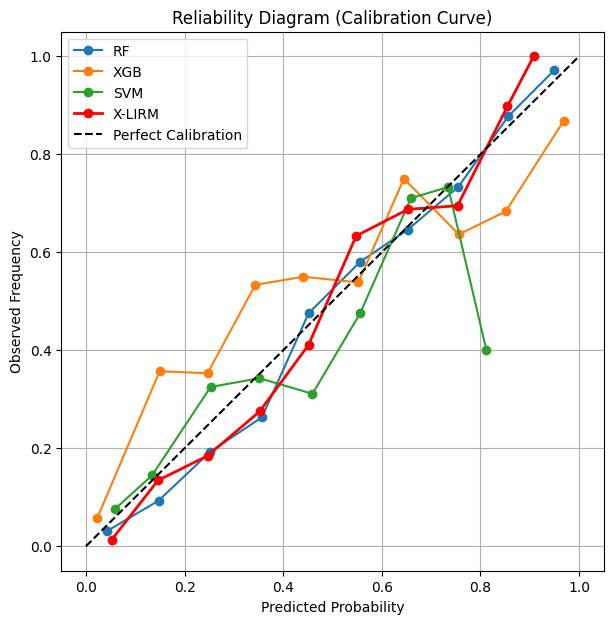

In [3]:
# ============================================================
# Reliability Diagram (Calibration Curve)
# ============================================================

from sklearn.calibration import calibration_curve

plt.figure(figsize=(7,7))

for name, model in base_models.items():

    probs = cross_val_predict(
        model,
        X_bal,
        y_bal,
        cv=skf,
        method="predict_proba"
    )[:,1]

    frac_pos, mean_pred = calibration_curve(y_bal, probs, n_bins=10)

    plt.plot(mean_pred, frac_pos, marker='o', label=name)

# X-LIRM meta learner
frac_pos_meta, mean_pred_meta = calibration_curve(y_bal, meta_score, n_bins=10)

plt.plot(mean_pred_meta, frac_pos_meta,
         marker='o',
         linewidth=2,
         color='red',
         label='X-LIRM')

# perfect calibration
plt.plot([0,1],[0,1], linestyle="--", color="black", label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Reliability Diagram (Calibration Curve)")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
# ============================================================
# Brier Score Calculation (Calibration Metric)
# ============================================================

from sklearn.metrics import brier_score_loss

print("\n===== Brier Score (Lower is Better) =====")

# Base models
for name, model in base_models.items():

    probs = cross_val_predict(
        model,
        X_bal,
        y_bal,
        cv=skf,
        method="predict_proba"
    )[:,1]

    brier = brier_score_loss(y_bal, probs)

    print(f"{name}: {brier:.4f}")

# X-LIRM meta learner
brier_meta = brier_score_loss(y_bal, meta_score)

print(f"X-LIRM: {brier_meta:.4f}")


===== Brier Score (Lower is Better) =====
RF: 0.1353
XGB: 0.1447
SVM: 0.1855
X-LIRM: 0.1363


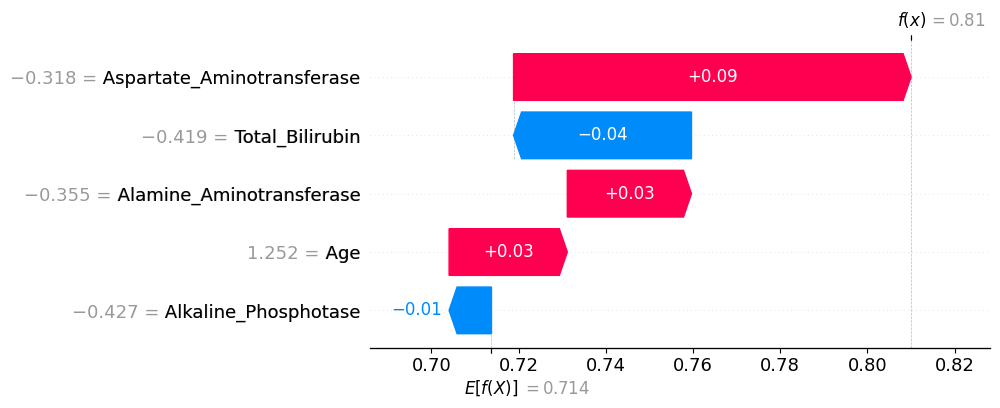

In [5]:
# ============================================================
# SHAP Waterfall Plot (Correct Fix)
# ============================================================

rf_explain = RandomForestClassifier(random_state=42)
rf_explain.fit(X_final, y)

explainer = shap.TreeExplainer(rf_explain)

# select sample
sample_index = 0
sample = X_final[sample_index].reshape(1,-1)

# compute shap values
shap_values = explainer(sample)

# select predicted class
pred_class = rf_explain.predict(sample)[0]

# create explanation for that class
exp = shap.Explanation(
    values=shap_values.values[0,:,pred_class],
    base_values=shap_values.base_values[0,pred_class],
    data=sample[0],
    feature_names=final_features
)

# waterfall plot showing all selected features
shap.plots.waterfall(exp, max_display=len(final_features))

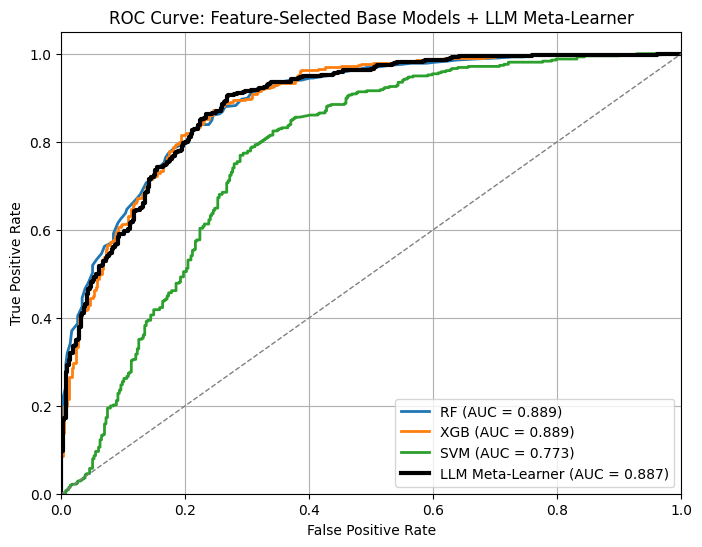

In [6]:
# ============================================================
# ROC Curve for Base Classifiers + LLM Meta-Learner
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

plt.figure(figsize=(8,6))

# -------- Base classifiers --------
for name, model in base_models.items():
    # Get fold-wise predicted probabilities
    y_prob = cross_val_predict(model, X_bal, y_bal, cv=skf, method="predict_proba")[:,1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_bal, y_prob)
    roc_auc_val = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc_val:.3f})")

# -------- LLM Meta-Learner --------
fpr_meta, tpr_meta, _ = roc_curve(y_bal, meta_score)
roc_auc_meta = auc(fpr_meta, tpr_meta)
plt.plot(fpr_meta, tpr_meta, color='black', lw=3, label=f"LLM Meta-Learner (AUC = {roc_auc_meta:.3f})")

# -------- Plot settings --------
plt.plot([0,1], [0,1], color='gray', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Feature-Selected Base Models + LLM Meta-Learner")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
